# Music Classification By Genre

## Data Set:

* GTZAN (Kaggle) : music genre classification

## Part 1: Classical Machine Learning Models

* SVM
* Random Forest
* k-Nearest Neighbors
* Gradient Boosting

### Evaluation Metrics

* accuracy
* precision
* recall
* F1 score
* confusion matrices
* ROC curves : one-vs-rest ROC curves
* AUC : macro- or micro-averaged AUC

### Tuning

* hyperparameter tuning
* compare the models in terms of performance, training time, and complexity

## 1.1 SVM (Support Vector Machines)

In [39]:
import pandas as pd

df = pd.read_csv('GTZAN_Data_Music_Genre_Classification/features_30_sec.csv')
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   str    
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             1000 non-nu

In [41]:
print(f'df.shape = {df.shape}')

df.shape = (1000, 60)


In [42]:
df.describe()

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,662030.846000,0.378682,0.086340,0.130930,0.003051,2201.780898,4.696916e+05,2242.541070,137079.155165,4571.549304,...,1.148144,60.730958,-3.966028,62.633624,0.507696,63.712586,-2.328761,66.231930,-1.095348,70.126096
std,1784.073992,0.081705,0.007735,0.065683,0.003634,715.960600,4.008995e+05,526.316473,96455.666326,1574.791602,...,4.578948,33.781951,4.549697,33.479172,3.869105,34.401977,3.755957,37.174631,3.837007,45.228512
min,660000.000000,0.171939,0.044555,0.005276,0.000004,570.040355,7.911251e+03,898.066208,10787.185064,749.140636,...,-15.693844,9.169314,-17.234728,13.931521,-11.963694,15.420555,-18.501955,13.487622,-19.929634,7.956583
25%,661504.000000,0.319562,0.082298,0.086657,0.000942,1627.697311,1.843505e+05,1907.240605,67376.554428,3380.069642,...,-1.863280,40.376442,-7.207225,40.830875,-2.007015,41.884240,-4.662925,41.710184,-3.368996,42.372865
50%,661794.000000,0.383148,0.086615,0.122443,0.001816,2209.263090,3.384862e+05,2221.392843,111977.548036,4658.524473,...,1.212809,52.325077,-4.065605,54.717674,0.669643,54.804890,-2.393862,57.423059,-1.166289,59.186117
75%,661794.000000,0.435942,0.091256,0.175682,0.003577,2691.294667,6.121479e+05,2578.469836,182371.576801,5533.810460,...,4.359662,71.691755,-0.838737,75.040838,3.119212,75.385832,0.150573,78.626444,1.312615,85.375374
max,675808.000000,0.663685,0.108111,0.397973,0.027679,4435.243901,3.036843e+06,3509.646417,694784.811549,8677.672688,...,13.457150,392.932373,11.482946,406.058868,15.388390,332.905426,14.694924,393.161987,15.369627,506.065155


In [43]:
# Drop filename column (values like 'jazz.00085.4.wav') which are not numeric
# and are not needed for training models
df = df.drop('filename', axis = 1)

# Define X (features) and y (targets aka labels)
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

print(f'X.shape = {X.shape}')
print(f'y.shape = {y.shape}')

X.shape = (1000, 58)
y.shape = (1000,)


In [57]:
from sklearn.model_selection import train_test_split

# Split data into training data (80%) and test data (20%)
# NOTE: stratify=y : split each class (music genre) separately
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42, stratify=y)

print(f'X_train.shape = {X_train.shape}')
print(f'y_train.shape = {y_train.shape}')
print(f'X_test.shape = {X_test.shape}')
print(f'y_test.shape = {y_test.shape}')

X_train.shape = (800, 58)
y_train.shape = (800,)
X_test.shape = (200, 58)
y_test.shape = (200,)


In [58]:
# Convert text-based labels like "blues" to numerical labels for better use in
# machine-learning algorithms

from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

y_train = labelencoder.fit_transform(y_train)
y_test = labelencoder.transform(y_test)

print(labelencoder.classes_)





['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [59]:
train_counts = pd.Series(y_train).value_counts().sort_index()
train_counts.index = labelencoder.classes_[train_counts.index]
print(train_counts)

blues        80
classical    80
country      80
disco        80
hiphop       80
jazz         80
metal        80
pop          80
reggae       80
rock         80
Name: count, dtype: int64


In [61]:
test_counts = pd.Series(y_test).value_counts().sort_index()
test_counts.index = labelencoder.classes_[test_counts.index]
print(test_counts)

blues        20
classical    20
country      20
disco        20
hiphop       20
jazz         20
metal        20
pop          20
reggae       20
rock         20
Name: count, dtype: int64


In [62]:
print(pd.Series(y_train).value_counts().sort_index())
print(pd.Series(y_test).value_counts().sort_index())

0    80
1    80
2    80
3    80
4    80
5    80
6    80
7    80
8    80
9    80
Name: count, dtype: int64
0    20
1    20
2    20
3    20
4    20
5    20
6    20
7    20
8    20
9    20
Name: count, dtype: int64


In [63]:
for i, label in enumerate(labelencoder.classes_):
    print(i, "->", label)

0 -> blues
1 -> classical
2 -> country
3 -> disco
4 -> hiphop
5 -> jazz
6 -> metal
7 -> pop
8 -> reggae
9 -> rock


### Feature Scaling with StandardScaler

In [64]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

### 1.1.1 Train SVM Model

In [65]:
from sklearn.svm import SVC
import time

svm = SVC(random_state=42)

svm_start_time = time.time()
svm.fit(X_train, y_train)
svm_end_time = time.time()
svm_training_time = svm_end_time - svm_start_time

print(f'SVM training time: {svm_training_time:.2f} seconds')
print(f'Number of support vectors per class: {svm.n_support_}')
print(f'Total support vectors: {svm.support_vectors_.shape[0]} of {X_train.shape[0]} training samples')


SVM training time: 0.04 seconds
Number of support vectors per class: [79 55 77 77 75 73 55 59 74 79]
Total support vectors: 703 of 800 training samples


### 1.1.2 Use trained SVM model to predict targets from test data

In [66]:
y_pred_svm = svm.predict(X_test)

print(f'Predictions shape: {y_pred_svm.shape}')
print(f'First 10 predicted: {y_pred_svm[:10]}')
print(f'First 10 actual:    {y_test[:10]}')

Predictions shape: (200,)
First 10 predicted: [1 0 3 5 0 9 9 2 4 5]
First 10 actual:    [1 0 6 5 0 2 9 2 4 5]


### 1.1.3 Calculate Accuracy Score for SVM

In [67]:
from sklearn.metrics import accuracy_score

train_accuracy_svm = accuracy_score(y_train, svm.predict(X_train))
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f'SVM Training accuracy: {train_accuracy_svm:.4f}')
print(f'SVM Testing accuracy:  {svm_accuracy:.4f}')

SVM Training accuracy: 0.8838
SVM Testing accuracy:  0.7350


### 1.1.4 Calculate Precision, Recal, and F1 Scores for SVM

In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score

svm_precision = precision_score(y_test, y_pred_svm, average='macro')
svm_recall    = recall_score(y_test, y_pred_svm, average='macro')
svm_f1        = f1_score(y_test, y_pred_svm, average='macro')

print(f'Precision (macro): {svm_precision:.4f}')
print(f'Recall (macro):    {svm_recall:.4f}')
print(f'F1 score (macro):  {svm_f1:.4f}')

Precision (macro): 0.7409
Recall (macro):    0.7350
F1 score (macro):  0.7340


### 1.1.5 Create Confusion Matrix for SVM

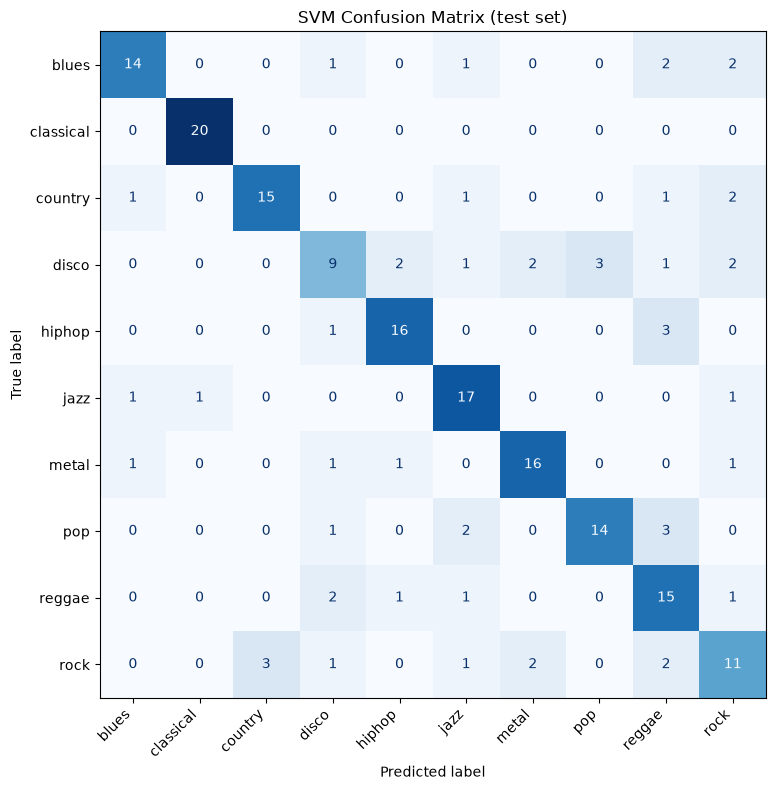

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay  # ,confusion_matrix
import matplotlib.pyplot as plt

# cm_svm = confusion_matrix(y_test, y_pred_svm)
# print(cm_svm)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                       display_labels=labelencoder.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_title('SVM Confusion Matrix (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.1.6 ROC Curves for SVM

y_score_svm shape: (200, 10)
y_test_bin shape:  (200, 10)
blues      AUC: 0.9625
classical  AUC: 0.9967
country    AUC: 0.9908
disco      AUC: 0.8772
hiphop     AUC: 0.9617
jazz       AUC: 0.9744
metal      AUC: 0.9503
pop        AUC: 0.9642
reggae     AUC: 0.9125
rock       AUC: 0.8572


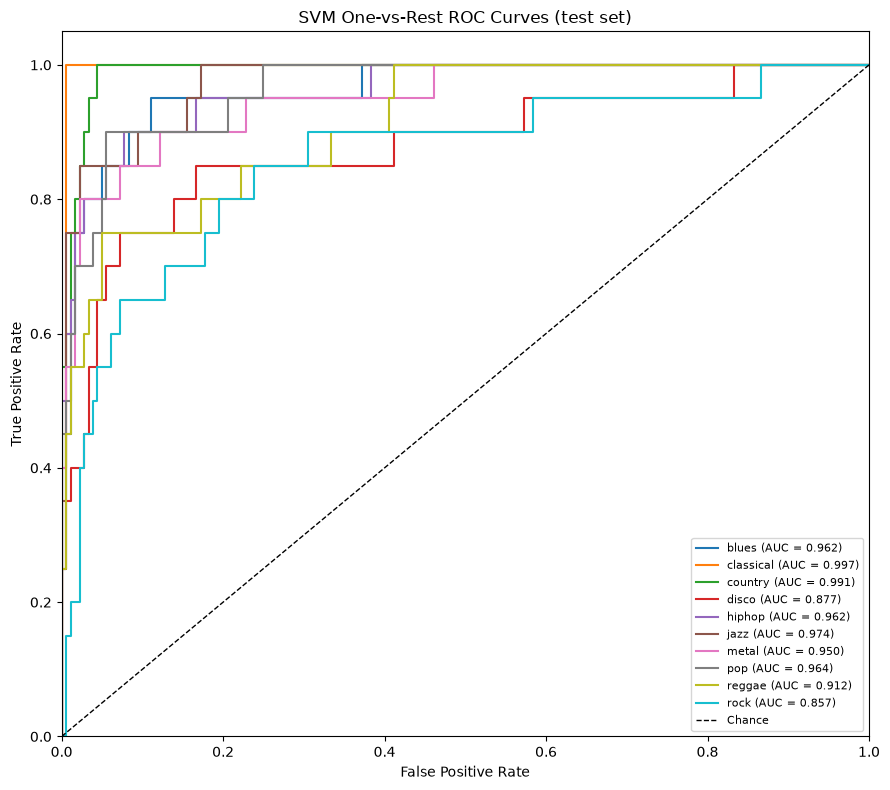

In [74]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_score_svm = svm.decision_function(X_test)
y_test_bin = label_binarize(y_test, classes=range(len(labelencoder.classes_)))

print(f'y_score_svm shape: {y_score_svm.shape}')
print(f'y_test_bin shape:  {y_test_bin.shape}')

n_classes = len(labelencoder.classes_)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

for i, label in enumerate(labelencoder.classes_):
    print(f'{label:10s} AUC: {roc_auc[i]:.4f}')

plt.figure(figsize=(9, 8))

for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr[i], tpr[i], lw=1.5,
             label=f'{label} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM One-vs-Rest ROC Curves (test set)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 1.1.7 Macro-averaged and Micro-averaged AUC for SVM

In [75]:
from sklearn.metrics import roc_auc_score

# Macro-average: unweighted mean of the per-class AUCs
roc_auc_macro = roc_auc_score(y_test_bin, y_score_svm, average='macro', multi_class='ovr')

# Micro-average: aggregate all TP/FP counts across classes first, then compute AUC
roc_auc_micro = roc_auc_score(y_test_bin, y_score_svm, average='micro')

print(f'Macro-averaged AUC: {roc_auc_macro:.4f}')
print(f'Micro-averaged AUC: {roc_auc_micro:.4f}')

Macro-averaged AUC: 0.9447
Micro-averaged AUC: 0.9463


### 1.1.8 Tuning of SVM

In [76]:
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

svm_grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_tuning_start_time = time.time()
svm_grid_search.fit(X_train, y_train)
svm_tuning_end_time = time.time()
svm_tuning_time = svm_tuning_end_time - svm_tuning_start_time

print(f'SVM hyperparameter tuning time: {svm_tuning_time:.2f} seconds')
print(f'Best parameters: {svm_grid_search.best_params_}')
print(f'Best cross-validation accuracy: {svm_grid_search.best_score_:.4f}')

SVM hyperparameter tuning time: 9.29 seconds
Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.7488


### 1.1.9 Check Accuracy of Original SVM vs. Tuned SVM

In [77]:
svm_tuned = svm_grid_search.best_estimator_

y_pred_svm_tuned = svm_tuned.predict(X_test)
svm_tuned_accuracy = accuracy_score(y_test, y_pred_svm_tuned)

print(f'Original SVM test accuracy: {svm_accuracy:.4f}')
print(f'Tuned SVM test accuracy:    {svm_tuned_accuracy:.4f}')
print(f'Improvement: {svm_tuned_accuracy - svm_accuracy:+.4f}')

Original SVM test accuracy: 0.7350
Tuned SVM test accuracy:    0.7650
Improvement: +0.0300


### 1.1.10 Re-compute metrics for the tuned SVM

In [78]:
svm_tuned_precision = precision_score(y_test, y_pred_svm_tuned, average='macro')
svm_tuned_recall    = recall_score(y_test, y_pred_svm_tuned, average='macro')
svm_tuned_f1        = f1_score(y_test, y_pred_svm_tuned, average='macro')

print('Original SVM  ->  Tuned SVM')
print(f'Precision (macro): {svm_precision:.4f}  ->  {svm_tuned_precision:.4f}')
print(f'Recall (macro):    {svm_recall:.4f}  ->  {svm_tuned_recall:.4f}')
print(f'F1 score (macro):  {svm_f1:.4f}  ->  {svm_tuned_f1:.4f}')

Original SVM  ->  Tuned SVM
Precision (macro): 0.7409  ->  0.7686
Recall (macro):    0.7350  ->  0.7650
F1 score (macro):  0.7340  ->  0.7643


### 1.1.11 Confusion Matrix for Tuned SVM

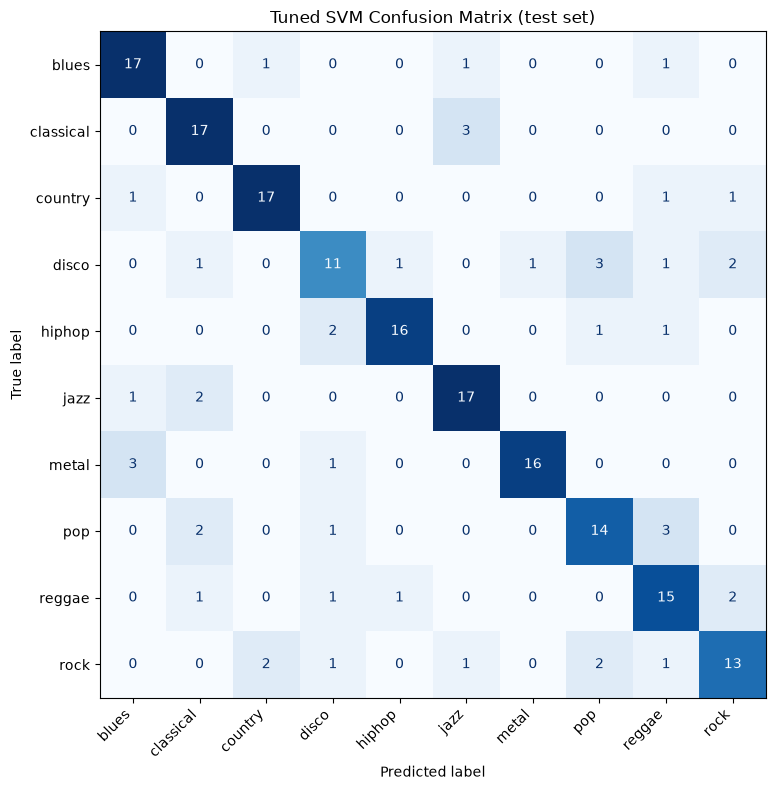

In [79]:
cm_svm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_svm_tuned,
                       display_labels=labelencoder.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_title('Tuned SVM Confusion Matrix (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.1.12 ROC curves for Tuned SVM

In [81]:
y_score_svm_tuned = svm_tuned.decision_function(X_test)

fpr_tuned = dict()
tpr_tuned = dict()
roc_auc_tuned = dict()

for i in range(n_classes):
    fpr_tuned[i], tpr_tuned[i], _ = roc_curve(y_test_bin[:, i], y_score_svm_tuned[:, i])
    roc_auc_tuned[i] = auc(fpr_tuned[i], tpr_tuned[i])

print('Class\t\tOriginal -> Tuned')
for i, label in enumerate(labelencoder.classes_):
    print(f'{label:10s}\t{roc_auc[i]:.4f} -> {roc_auc_tuned[i]:.4f}')

Class		Original -> Tuned
blues     	0.9625 -> 0.9731
classical 	0.9967 -> 0.9933
country   	0.9908 -> 0.9869
disco     	0.8772 -> 0.8639
hiphop    	0.9617 -> 0.9636
jazz      	0.9744 -> 0.9764
metal     	0.9503 -> 0.9650
pop       	0.9642 -> 0.9492
reggae    	0.9125 -> 0.9233
rock      	0.8572 -> 0.8414


## NOTE: classification of some genres improved due to SVM model tuning, but some got worse.  Although the grid search optimized for overall accuracy, it did not optimize for per-class AUC.

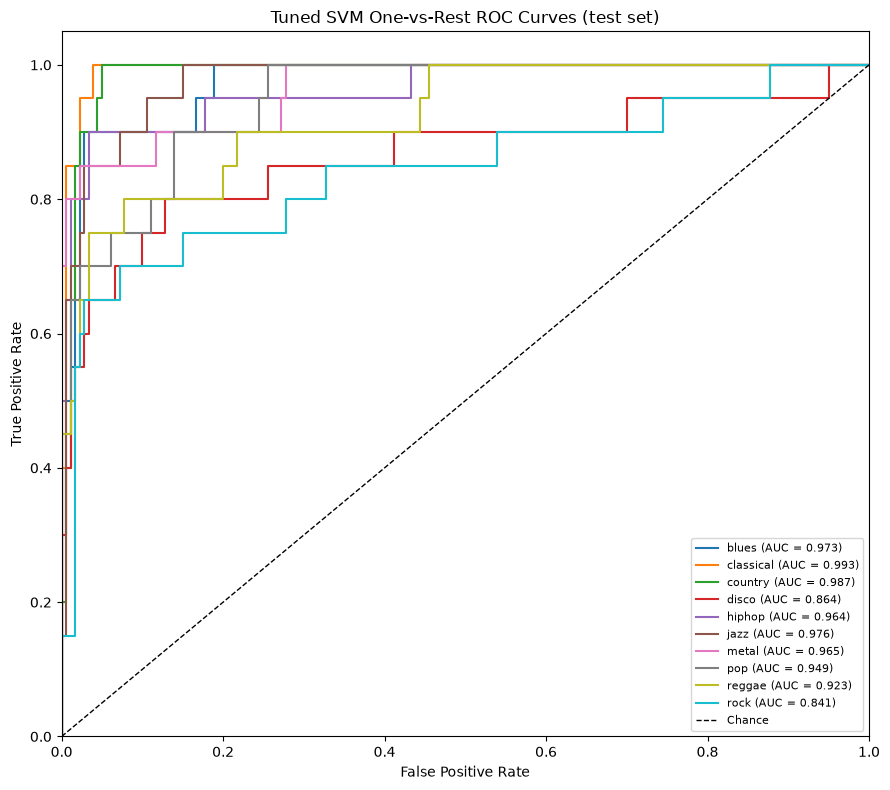

In [82]:
plt.figure(figsize=(9, 8))

for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr_tuned[i], tpr_tuned[i], lw=1.5,
             label=f'{label} (AUC = {roc_auc_tuned[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned SVM One-vs-Rest ROC Curves (test set)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 1.1.13 SVM (tuned): Macro-averaged and Micro-averaged AUC (Area Under the Curve)

In [83]:
roc_auc_macro_tuned = roc_auc_score(y_test_bin, y_score_svm_tuned, average='macro', multi_class='ovr')
roc_auc_micro_tuned = roc_auc_score(y_test_bin, y_score_svm_tuned, average='micro')

print('Metric                Original -> Tuned')
print(f'Macro-averaged AUC:   {roc_auc_macro:.4f}   -> {roc_auc_macro_tuned:.4f}')
print(f'Micro-averaged AUC:   {roc_auc_micro:.4f}   -> {roc_auc_micro_tuned:.4f}')

Metric                Original -> Tuned
Macro-averaged AUC:   0.9447   -> 0.9436
Micro-averaged AUC:   0.9463   -> 0.9453


# 1.2 Random Forest

## the "forest" is built from a group of decision trees

### 1.2.1 Random Forest : Train the default model and time it

In [87]:
from sklearn.ensemble import RandomForestClassifier

# NOTE: rf is short for random forest
rf = RandomForestClassifier(random_state=42)

rf_start_time = time.time()
rf.fit(X_train, y_train)
rf_end_time = time.time()
rf_training_time = rf_end_time - rf_start_time

print(f'Random Forest training time: {rf_training_time:.2f} seconds')
print(f'Number of trees: {rf.n_estimators}')
print(f'Average tree depth: {sum(tree.tree_.max_depth for tree in rf.estimators_) / len(rf.estimators_):.1f}')

Random Forest training time: 0.51 seconds
Number of trees: 100
Average tree depth: 15.5


### 1.2.2 Random Forest (untuned): Predict on the test set, and compute accuracy

In [88]:
y_pred_rf = rf.predict(X_test)

train_accuracy_rf = accuracy_score(y_train, rf.predict(X_train))
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest Training accuracy: {train_accuracy_rf:.4f}')
print(f'Random Forest Testing accuracy:  {rf_accuracy:.4f}')

Random Forest Training accuracy: 0.9988
Random Forest Testing accuracy:  0.7750


### NOTE: the difference between these two accuracy numbers suggests overfitting.  I will attempt to address this by tuning the model in a later step.

### 1.2.3 Random Forest (untuned): Precision, Recall, F1 scores:

In [89]:
rf_precision = precision_score(y_test, y_pred_rf, average='macro')
rf_recall    = recall_score(y_test, y_pred_rf, average='macro')
rf_f1        = f1_score(y_test, y_pred_rf, average='macro')

print(f'Precision (macro): {rf_precision:.4f}')
print(f'Recall (macro):    {rf_recall:.4f}')
print(f'F1 score (macro):  {rf_f1:.4f}')

Precision (macro): 0.7745
Recall (macro):    0.7750
F1 score (macro):  0.7720


### NOTE: scores for Random Forest are higher than scores for SVM

### 1.2.4 Random Forest (untuned): Confusion Matrix

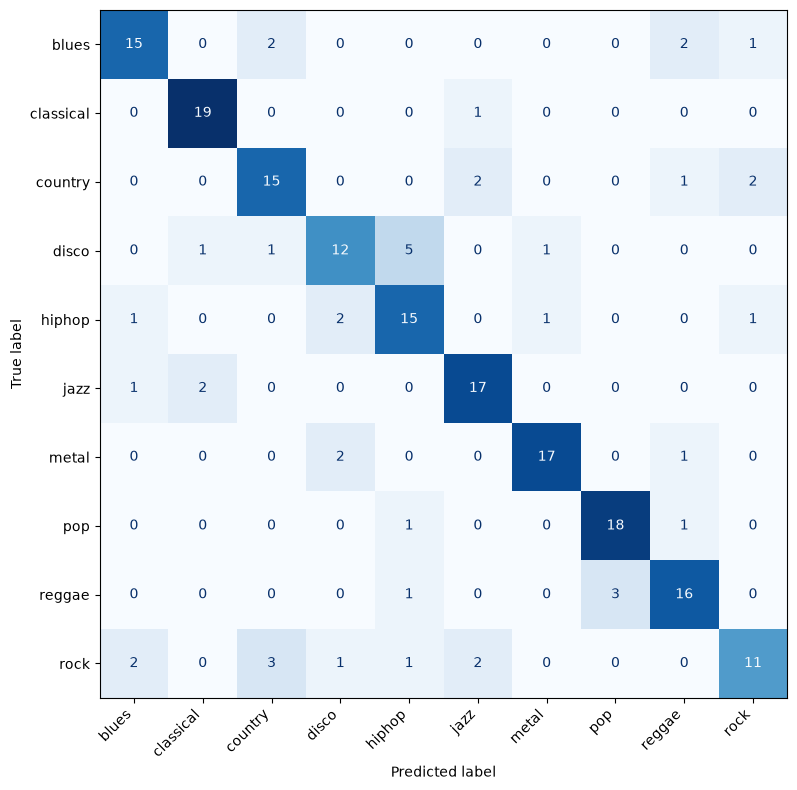

In [91]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

figure, axis = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                       display_labels=labelencoder.classes_).plot(
    ax=axis, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_title('Random Forest Confusion Matrix (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.2.5 Random Forest (untuned): ROC curves

In [92]:
y_score_rf = rf.predict_proba(X_test)

fpr_rf = dict()
tpr_rf = dict()
roc_auc_rf = dict()

for i in range(n_classes):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

print('Class       SVM (tuned) -> Random Forest')
for i, label in enumerate(labelencoder.classes_):
    print(f'{label:10s} {roc_auc_tuned[i]:.4f}       -> {roc_auc_rf[i]:.4f}')

Class       SVM (tuned) -> Random Forest
blues      0.9731       -> 0.9808
classical  0.9933       -> 0.9972
country    0.9869       -> 0.9694
disco      0.8639       -> 0.9313
hiphop     0.9636       -> 0.9701
jazz       0.9764       -> 0.9914
metal      0.9650       -> 0.9825
pop        0.9492       -> 0.9940
reggae     0.9233       -> 0.9650
rock       0.8414       -> 0.9107


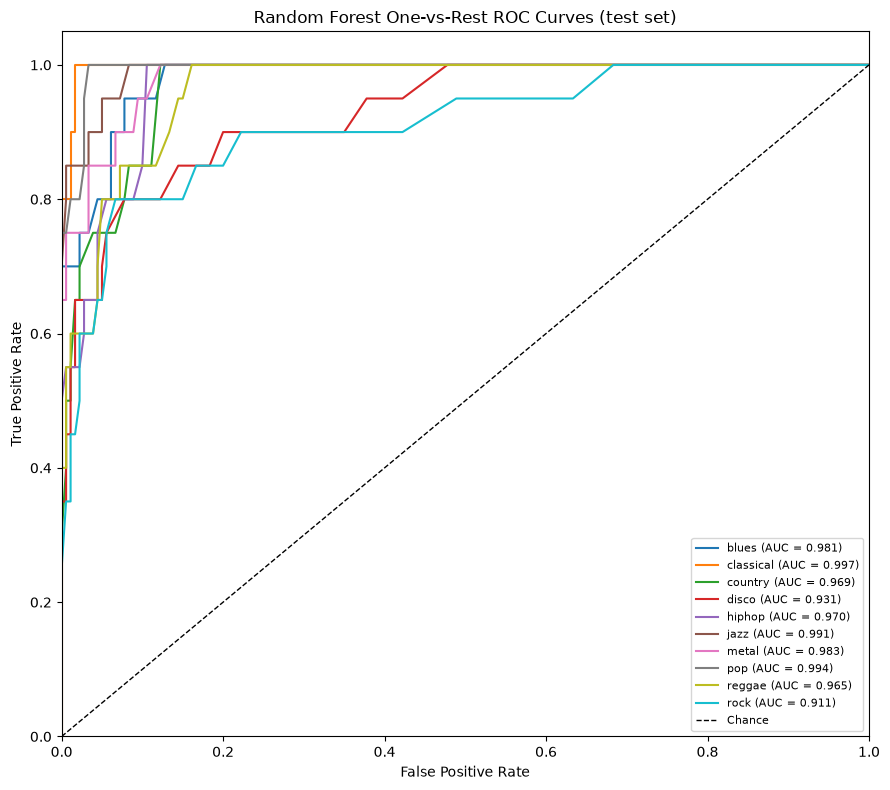

In [93]:
plt.figure(figsize=(9, 8))

for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr_rf[i], tpr_rf[i], lw=1.5,
             label=f'{label} (AUC = {roc_auc_rf[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest One-vs-Rest ROC Curves (test set)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 1.2.6 Random Forest (untuned): macro/micro AUC (Area Under the Curve)

In [94]:
roc_auc_macro_rf = roc_auc_score(y_test_bin, y_score_rf, average='macro', multi_class='ovr')
roc_auc_micro_rf = roc_auc_score(y_test_bin, y_score_rf, average='micro')

print('Metric              Tuned SVM -> Random Forest')
print(f'Macro-averaged AUC: {roc_auc_macro_tuned:.4f}   -> {roc_auc_macro_rf:.4f}')
print(f'Micro-averaged AUC: {roc_auc_micro_tuned:.4f}   -> {roc_auc_micro_rf:.4f}')

Metric              Tuned SVM -> Random Forest
Macro-averaged AUC: 0.9436   -> 0.9693
Micro-averaged AUC: 0.9453   -> 0.9725


### NOTE: "macro-averaged" is a single overall number when there are more than two classes. It is computed separately for each class, then combined as an unweighted average across all of the classes. It is an average of 10 AUCs in this scenario.

### "micro-averaged" combines all of the one-vs-rest problems into a single flat dataset, and is a metric of the pooled data. It is one AUC of all 2000 label/score pairs (200 samples * 10 classes), in this scenario.

### 1.2.7 Hyperparameter Tuning of Random Forest

#### NOTE: the untuned version (1.2.2) showed overfitting. Let's see if we can improve the model now.
#### Parameters to consider:
* n_estimators (number of trees)
* max_depth (how deep each tree can grow - changing this may help limit overfitting)
* min_samples_split, and min_samples_leaf (both control how much data a node needs before splitting further)

In [95]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_tuning_start_time = time.time()
rf_grid_search.fit(X_train, y_train)
rf_tuning_end_time = time.time()
rf_tuning_time = rf_tuning_end_time - rf_tuning_start_time

print(f'Random Forest hyperparameter tuning time: {rf_tuning_time:.2f} seconds')
print(f'Best parameters: {rf_grid_search.best_params_}')
print(f'Best cross-validation accuracy: {rf_grid_search.best_score_:.4f}')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Random Forest hyperparameter tuning time: 112.15 seconds
Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation accuracy: 0.7712


#### evaluate the tuned model on the test set, and check both train and test accuracy this time so we can directly see whether the overfitting gap closed

In [96]:
rf_tuned = rf_grid_search.best_estimator_

y_pred_rf_tuned = rf_tuned.predict(X_test)

train_accuracy_rf_tuned = accuracy_score(y_train, rf_tuned.predict(X_train))
rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)

print('              Train    Test     Gap')
print(f'Original RF:  {train_accuracy_rf:.4f}   {rf_accuracy:.4f}   {train_accuracy_rf - rf_accuracy:.4f}')
print(f'Tuned RF:     {train_accuracy_rf_tuned:.4f}   {rf_tuned_accuracy:.4f}   {train_accuracy_rf_tuned - rf_tuned_accuracy:.4f}')

              Train    Test     Gap
Original RF:  0.9988   0.7750   0.2238
Tuned RF:     0.9988   0.8200   0.1788


#### NOTE: tuned Random Forest has better performance against test data, while maintaining the same performance against training data

### 1.2.8 Random Forest (tuned): Precision, Recall, F1 scores

In [97]:
rf_tuned_precision = precision_score(y_test, y_pred_rf_tuned, average='macro')
rf_tuned_recall    = recall_score(y_test, y_pred_rf_tuned, average='macro')
rf_tuned_f1        = f1_score(y_test, y_pred_rf_tuned, average='macro')

print('Original RF  ->  Tuned RF')
print(f'Precision (macro): {rf_precision:.4f}  ->  {rf_tuned_precision:.4f}')
print(f'Recall (macro):    {rf_recall:.4f}  ->  {rf_tuned_recall:.4f}')
print(f'F1 score (macro):  {rf_f1:.4f}  ->  {rf_tuned_f1:.4f}')

Original RF  ->  Tuned RF
Precision (macro): 0.7745  ->  0.8205
Recall (macro):    0.7750  ->  0.8200
F1 score (macro):  0.7720  ->  0.8180


### 1.2.9 Random Forest (tuned): Confusion Matrix

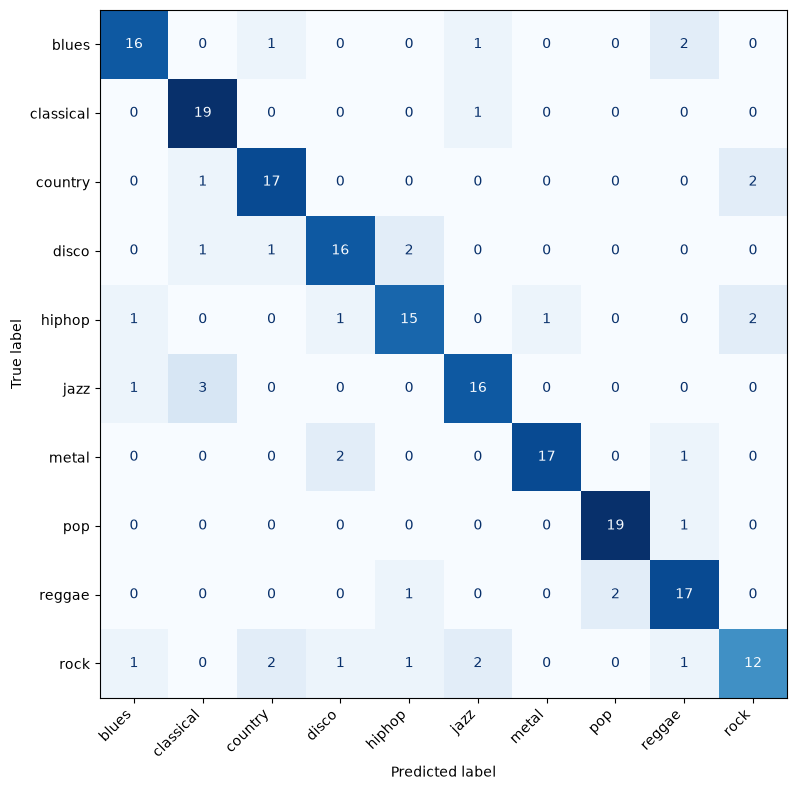

In [98]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

figure, axis = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned,
                       display_labels=labelencoder.classes_).plot(
    ax=axis, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_title('Tuned Random Forest Confusion Matrix (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### NOTE: the "rock" music genre is not categorized as accurately as other genres

### 1.2.10 Random Forest (tuned): ROC (Receiver Operating Characteristic) curves
#### describes the tradeoff between true positive rate and false positive rate as the classification threshold is adjusted

In [103]:
y_score_rf_tuned = rf_tuned.predict_proba(X_test)

fpr_rf_tuned = dict()
tpr_rf_tuned = dict()
roc_auc_rf_tuned = dict()

for i in range(n_classes):
    fpr_rf_tuned[i], tpr_rf_tuned[i], _ = roc_curve(y_test_bin[:, i], y_score_rf_tuned[:, i])
    roc_auc_rf_tuned[i] = auc(fpr_rf_tuned[i], tpr_rf_tuned[i])

print('Class\t RF (baseline) ->\tRF (tuned)')
for i, label in enumerate(labelencoder.classes_):
    print(f'{label:10s}\t{roc_auc_rf[i]:.4f} ->\t{roc_auc_rf_tuned[i]:.4f}')

Class	 RF (baseline) ->	RF (tuned)
blues     	0.9808 ->	0.9853
classical 	0.9972 ->	0.9969
country   	0.9694 ->	0.9844
disco     	0.9313 ->	0.9422
hiphop    	0.9701 ->	0.9742
jazz      	0.9914 ->	0.9878
metal     	0.9825 ->	0.9861
pop       	0.9940 ->	0.9972
reggae    	0.9650 ->	0.9642
rock      	0.9107 ->	0.9347


### NOTE: AUC for "rock" class actually improved, even though confusion matrix count was still low. Accuracy and AUC are different measurements. The tuned model has fewer confidently-wrong predictions for "rock", but borderline cases were classified wrong.

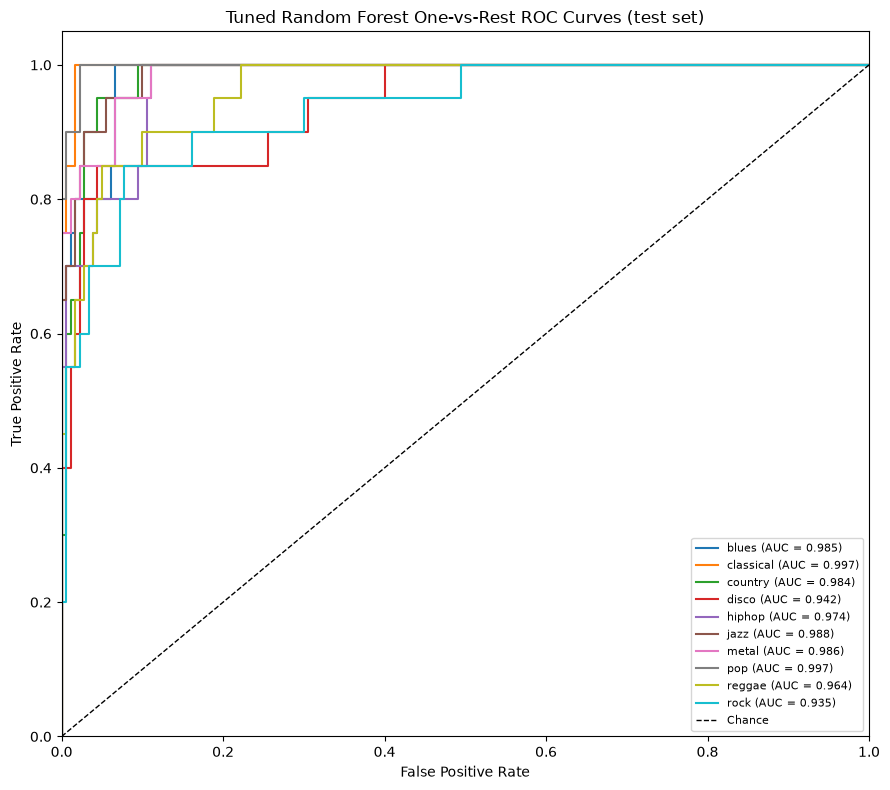

In [104]:
plt.figure(figsize=(9, 8))

for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr_rf_tuned[i], tpr_rf_tuned[i], lw=1.5,
             label=f'{label} (AUC = {roc_auc_rf_tuned[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned Random Forest One-vs-Rest ROC Curves (test set)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 1.2.11 Random Forest (tuned): macro/micro averaged AUC

In [105]:
roc_auc_macro_rf_tuned = roc_auc_score(y_test_bin, y_score_rf_tuned, average='macro', multi_class='ovr')
roc_auc_micro_rf_tuned = roc_auc_score(y_test_bin, y_score_rf_tuned, average='micro')

print('Metric              Baseline RF -> Tuned RF')
print(f'Macro-averaged AUC: {roc_auc_macro_rf:.4f}     -> {roc_auc_macro_rf_tuned:.4f}')
print(f'Micro-averaged AUC: {roc_auc_micro_rf:.4f}     -> {roc_auc_micro_rf_tuned:.4f}')

Metric              Baseline RF -> Tuned RF
Macro-averaged AUC: 0.9693     -> 0.9753
Micro-averaged AUC: 0.9725     -> 0.9770


### NOTE: Random Forest (Tuned) is the best so far, with Test Accuracy 0.8200 vs. SVM Tuned Accuracy 0.7650
### It also handled the "disco" genre better than SVM

### 1.3.1 k-Nearest Neighbors: Train Model, and time it

#### NOTE: kNN doesn't do much in the fit step, so that should be extremely fast.  The algorithm does more computation later when comparing distances during evalutation of each test data item

In [106]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn_start_time = time.time()
knn.fit(X_train, y_train)
knn_end_time = time.time()
knn_training_time = knn_end_time - knn_start_time

print(f'k-NN training time: {knn_training_time:.4f} seconds')
print(f'Number of neighbors (k): {knn.n_neighbors}')

k-NN training time: 0.0033 seconds
Number of neighbors (k): 5


In [107]:
knn_predict_start_time = time.time()
y_pred_knn = knn.predict(X_test)
knn_predict_end_time = time.time()
knn_predict_time = knn_predict_end_time - knn_predict_start_time

train_accuracy_knn = accuracy_score(y_train, knn.predict(X_train))
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f'k-NN prediction time (200 test samples): {knn_predict_time:.4f} seconds')
print(f'k-NN Training accuracy: {train_accuracy_knn:.4f}')
print(f'k-NN Testing accuracy:  {knn_accuracy:.4f}')

k-NN prediction time (200 test samples): 0.1038 seconds
k-NN Training accuracy: 0.8087
k-NN Testing accuracy:  0.6750


#### NOTE: the k=5 will be tuned in a step below for possible improvement in performance

### 1.3.2 k-NN (baseline): Precision, Recall, F1 scores

In [108]:
knn_precision = precision_score(y_test, y_pred_knn, average='macro')
knn_recall    = recall_score(y_test, y_pred_knn, average='macro')
knn_f1        = f1_score(y_test, y_pred_knn, average='macro')

print(f'Precision (macro): {knn_precision:.4f}')
print(f'Recall (macro):    {knn_recall:.4f}')
print(f'F1 score (macro):  {knn_f1:.4f}')

Precision (macro): 0.6920
Recall (macro):    0.6750
F1 score (macro):  0.6745


### 1.3.3 k-NN (baseline): Confusion Matrix

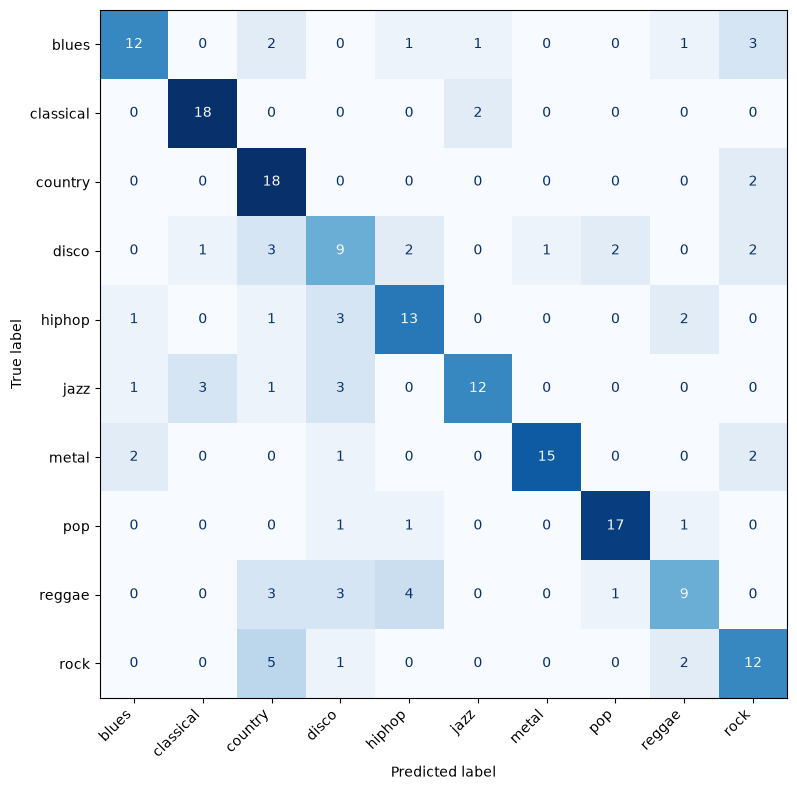

In [109]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

figure, axis = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                       display_labels=labelencoder.classes_).plot(
    ax=axis, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_title('k-NN Confusion Matrix (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.3.4 k-NN (baseline): ROC curves

In [110]:
y_score_knn = knn.predict_proba(X_test)

fpr_knn = dict()
tpr_knn = dict()
roc_auc_knn = dict()

for i in range(n_classes):
    fpr_knn[i], tpr_knn[i], _ = roc_curve(y_test_bin[:, i], y_score_knn[:, i])
    roc_auc_knn[i] = auc(fpr_knn[i], tpr_knn[i])

for i, label in enumerate(labelencoder.classes_):
    print(f'{label:10s} AUC: {roc_auc_knn[i]:.4f}')

blues      AUC: 0.9251
classical  AUC: 0.9953
country    AUC: 0.9468
disco      AUC: 0.8214
hiphop     AUC: 0.9515
jazz       AUC: 0.9547
metal      AUC: 0.8889
pop        AUC: 0.9874
reggae     AUC: 0.8665
rock       AUC: 0.8639


#### NOTE: k-NN has lower performance here for the "metal" genre class than SVM and Random Forest models above

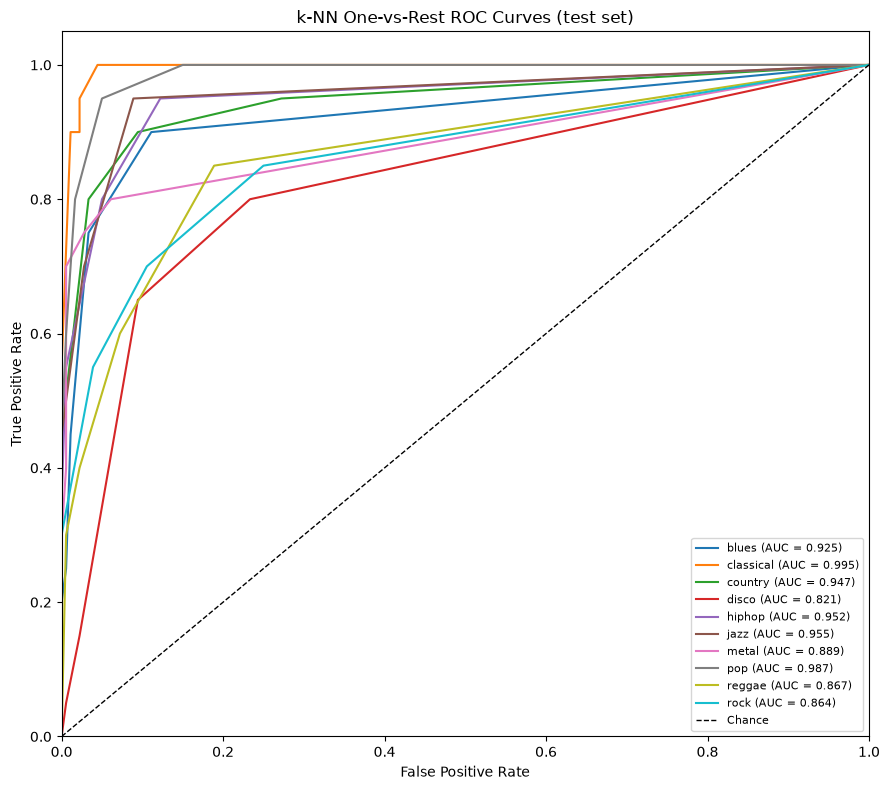

In [111]:
plt.figure(figsize=(9, 8))

for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr_knn[i], tpr_knn[i], lw=1.5,
             label=f'{label} (AUC = {roc_auc_knn[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('k-NN One-vs-Rest ROC Curves (test set)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

#### NOTE: these curves are more angular / straight-edged, instead of the staircase shapes for earlier SVM and Random Forest models. This is because, with default k=5, each class probability can only take 6 possible values. These are fewer distinct values than the decision scores of SVM or probabilities of Random Forest.

### 1.3.5 k-NN (baseline): macro/micro AUC (area under curve):

In [112]:
roc_auc_macro_knn = roc_auc_score(y_test_bin, y_score_knn, average='macro', multi_class='ovr')
roc_auc_micro_knn = roc_auc_score(y_test_bin, y_score_knn, average='micro')

print(f'Macro-averaged AUC: {roc_auc_macro_knn:.4f}')
print(f'Micro-averaged AUC: {roc_auc_micro_knn:.4f}')

Macro-averaged AUC: 0.9202
Micro-averaged AUC: 0.9218


#### NOTE: k-NN (baseline, not tuned) performance is weaker than SVM and Random Forest

### 1.3.6 k-NN hyperparameter tuning

* k (number of neighbors)
* weights ('uniform' treats all k neighbors equally, 'distance' weights closer neighbors more heavily)
* distance metric (Euclidean vs Manhattan, etc.).

In [113]:
parameter_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid_search = GridSearchCV(
    KNeighborsClassifier(),
    parameter_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

knn_tuning_start_time = time.time()
knn_grid_search.fit(X_train, y_train)
knn_tuning_end_time = time.time()
knn_tuning_time = knn_tuning_end_time - knn_tuning_start_time

print(f'k-NN hyperparameter tuning time: {knn_tuning_time:.2f} seconds')
print(f'Best parameters: {knn_grid_search.best_params_}')
print(f'Best cross-validation accuracy: {knn_grid_search.best_score_:.4f}')

k-NN hyperparameter tuning time: 5.58 seconds
Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best cross-validation accuracy: 0.7025


### 1.3.7. k-NN (tuned): Evaluate on the test data set and compute accuracy:

In [114]:
knn_tuned = knn_grid_search.best_estimator_

y_pred_knn_tuned = knn_tuned.predict(X_test)
knn_tuned_accuracy = accuracy_score(y_test, y_pred_knn_tuned)

print(f'Original k-NN test accuracy: {knn_accuracy:.4f}')
print(f'Tuned k-NN test accuracy:    {knn_tuned_accuracy:.4f}')
print(f'Improvement: {knn_tuned_accuracy - knn_accuracy:+.4f}')

Original k-NN test accuracy: 0.6750
Tuned k-NN test accuracy:    0.6900
Improvement: +0.0150


### 1.3.8.  k-NN (tuned): Precision, Recall, F1 scores:

In [115]:
knn_tuned_precision = precision_score(y_test, y_pred_knn_tuned, average='macro')
knn_tuned_recall    = recall_score(y_test, y_pred_knn_tuned, average='macro')
knn_tuned_f1        = f1_score(y_test, y_pred_knn_tuned, average='macro')

print('Original k-NN  ->  Tuned k-NN')
print(f'Precision (macro): {knn_precision:.4f}  ->  {knn_tuned_precision:.4f}')
print(f'Recall (macro):    {knn_recall:.4f}  ->  {knn_tuned_recall:.4f}')
print(f'F1 score (macro):  {knn_f1:.4f}  ->  {knn_tuned_f1:.4f}')


Original k-NN  ->  Tuned k-NN
Precision (macro): 0.6920  ->  0.7079
Recall (macro):    0.6750  ->  0.6900
F1 score (macro):  0.6745  ->  0.6903


### 1.3.9.  k-NN (tuned): Confusion Matrix:

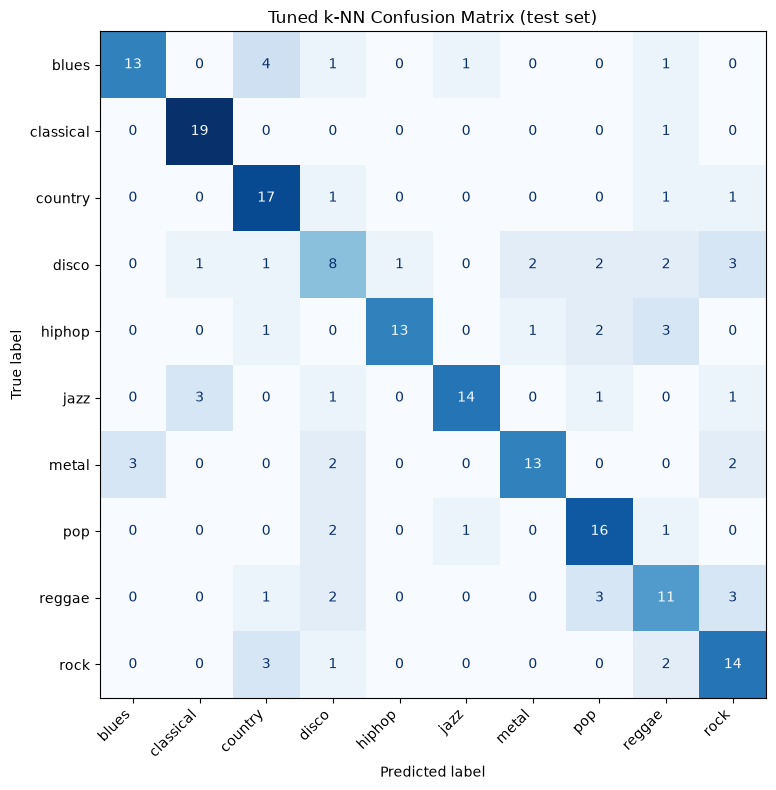

In [116]:
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)

figure, axis = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_knn_tuned,
                       display_labels=labelencoder.classes_).plot(
    ax=axis, cmap='Blues', colorbar=False, values_format='d'
)
axis.set_title('Tuned k-NN Confusion Matrix (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### NOTE: tuning k-NN shifted the performance across different classes (music genres), but did not significantly improve accuracy overall

### 1.3.10.  k-NN (tuned): ROC curves:

In [117]:
y_score_knn_tuned = knn_tuned.predict_proba(X_test)

fpr_knn_tuned = dict()
tpr_knn_tuned = dict()
roc_auc_knn_tuned = dict()

for i in range(n_classes):
    fpr_knn_tuned[i], tpr_knn_tuned[i], _ = roc_curve(y_test_bin[:, i], y_score_knn_tuned[:, i])
    roc_auc_knn_tuned[i] = auc(fpr_knn_tuned[i], tpr_knn_tuned[i])

print('Class\tk-NN (baseline)\t->\tk-NN (tuned)')
for i, label in enumerate(labelencoder.classes_):
    print(f'{label:10s}\t{roc_auc_knn[i]:.4f}\t->\t{roc_auc_knn_tuned[i]:.4f}')

Class	k-NN (baseline)	->	k-NN (tuned)
blues     	0.9251	->	0.9144
classical 	0.9953	->	0.9978
country   	0.9468	->	0.9822
disco     	0.8214	->	0.7961
hiphop    	0.9515	->	0.9111
jazz      	0.9547	->	0.9664
metal     	0.8889	->	0.8650
pop       	0.9874	->	0.9381
reggae    	0.8665	->	0.8335
rock      	0.8639	->	0.8457


#### NOTE: some genres actually got WORSE in the tuned version (blues, disco, hiphop, metal, pop, reggae, rock), while a smaller number of classes improved (classical, country, jazz)

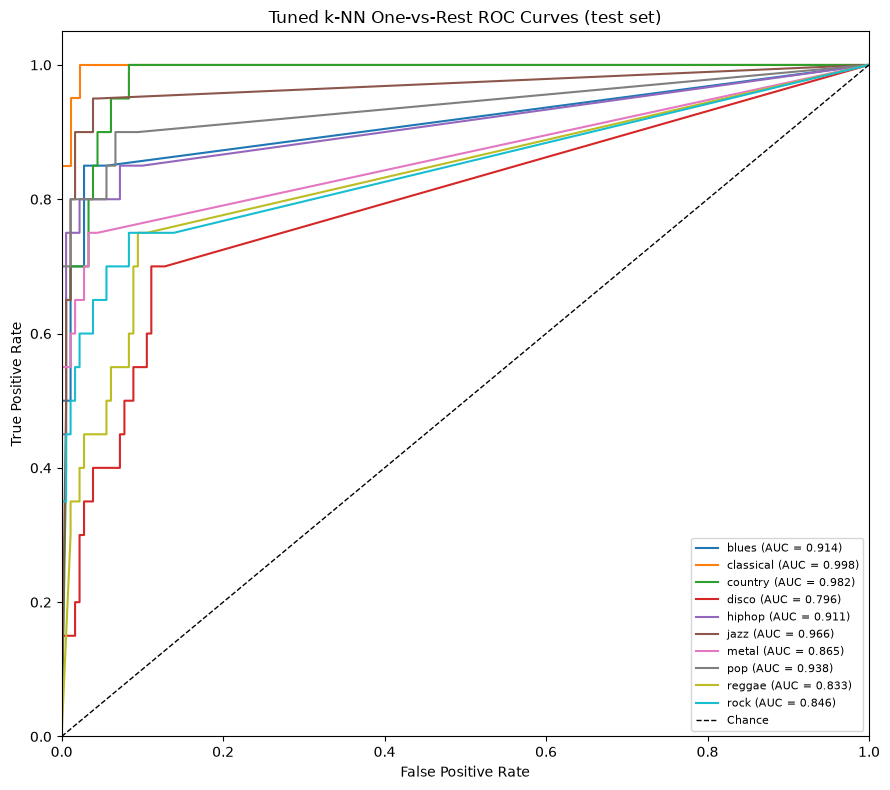

In [118]:
plt.figure(figsize=(9, 8))

for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr_knn_tuned[i], tpr_knn_tuned[i], lw=1.5,
             label=f'{label} (AUC = {roc_auc_knn_tuned[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned k-NN One-vs-Rest ROC Curves (test set)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 1.3.11.  k-NN (tuned): macro/micro AUC:

In [120]:
roc_auc_macro_knn_tuned = roc_auc_score(y_test_bin, y_score_knn_tuned, average='macro', multi_class='ovr')
roc_auc_micro_knn_tuned = roc_auc_score(y_test_bin, y_score_knn_tuned, average='micro')

print('Metric\t\tBaseline k-NN\t->\tTuned k-NN')
print(f'Macro-averaged AUC:\t{roc_auc_macro_knn:.4f}\t->\t{roc_auc_macro_knn_tuned:.4f}')
print(f'Micro-averaged AUC:\t{roc_auc_micro_knn:.4f}\t->\t{roc_auc_micro_knn_tuned:.4f}')

Metric		Baseline k-NN	->	Tuned k-NN
Macro-averaged AUC:	0.9202	->	0.9050
Micro-averaged AUC:	0.9218	->	0.9059


#### NOTE: unfortunately, tuning k-NN did not help its AUC here, despite the fact that the accuracy increased in step 1.3.7 above (Original k-NN test accuracy: 0.6750 vs. Tuned k-NN test accuracy: 0.6900). AUC does not always go up when accuracy goes up.

## 1.4 Gradient Boosting

### 1.4.1.  Gradient Boosting (baseline): Train the Default Model and Time It

In [122]:
from sklearn.ensemble import GradientBoostingClassifier

#
# NOTE: gb is short for Gradient Boosting, to save typing
#
gb = GradientBoostingClassifier(random_state=42)

gb_start_time = time.time()
gb.fit(X_train, y_train)
gb_end_time = time.time()
gb_training_time = gb_end_time - gb_start_time

print(f'Gradient Boosting training time: {gb_training_time:.2f} seconds')
print(f'Number of estimators (trees): {gb.n_estimators}')
print(f'Learning rate: {gb.learning_rate}')
print(f'Max depth per tree: {gb.max_depth}')

Gradient Boosting training time: 9.87 seconds
Number of estimators (trees): 100
Learning rate: 0.1
Max depth per tree: 3


#### NOTE: Gradient Boosting uses a sequential tree-building approach, so the training time is slower than Random Forest's training time. This is expected.

### 1.4.2 Gradient Boosting (baseline): Predictions of Test Data, and Accuracy Measurements:

In [123]:
y_pred_gb = gb.predict(X_test)

train_accuracy_gb = accuracy_score(y_train, gb.predict(X_train))
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f'Gradient Boosting Training accuracy: {train_accuracy_gb:.4f}')
print(f'Gradient Boosting Testing accuracy:  {gb_accuracy:.4f}')

Gradient Boosting Training accuracy: 0.9988
Gradient Boosting Testing accuracy:  0.7800


#### NOTE: the difference between 0.9988 and 0.7800 suggests that the model overfitted the training data. This was the same problem encountered earlier with Random Forest.

### 1.4.3.  Gradient Boosting (baseline): Precision, Recall, F1:

In [124]:
gb_precision = precision_score(y_test, y_pred_gb, average='macro')
gb_recall    = recall_score(y_test, y_pred_gb, average='macro')
gb_f1        = f1_score(y_test, y_pred_gb, average='macro')

print(f'Precision (macro): {gb_precision:.4f}')
print(f'Recall (macro):    {gb_recall:.4f}')
print(f'F1 score (macro):  {gb_f1:.4f}')

Precision (macro): 0.7862
Recall (macro):    0.7800
F1 score (macro):  0.7806


### 1.4.4.  Gradient Boosting (baseline): Confusion Matrix:

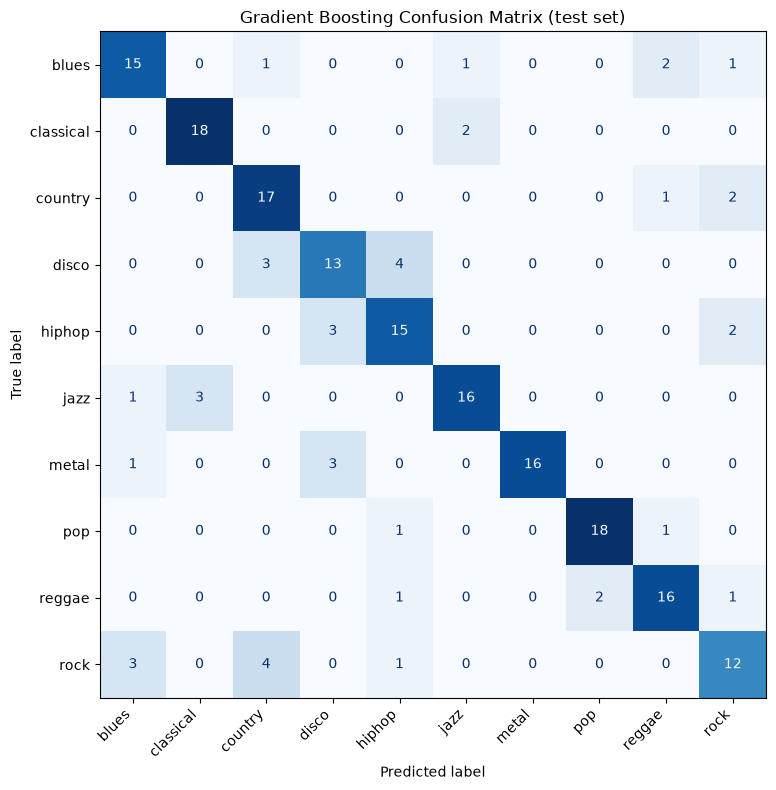

In [125]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_gb,
                       display_labels=labelencoder.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_title('Gradient Boosting Confusion Matrix (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### NOTE: as with earlier models considered, the classification of "rock" and "disco" music genres for the dataset is a problem.  This most likely indicates an issue with the data set or true similarity of those audio samples with audio samples labelled as other genres, and overlap of audio properties of the genres in general. It is hard for the machine learning models to accurately determine which samples should be assigned to those classes.

### 1.4.5.  Gradient Boosting (baseline): AUC (area under curve) and plot of ROC curves:

blues      AUC: 0.9781
classical  AUC: 0.9953
country    AUC: 0.9708
disco      AUC: 0.9658
hiphop     AUC: 0.9753
jazz       AUC: 0.9839
metal      AUC: 0.9861
pop        AUC: 0.9950
reggae     AUC: 0.9681
rock       AUC: 0.9519


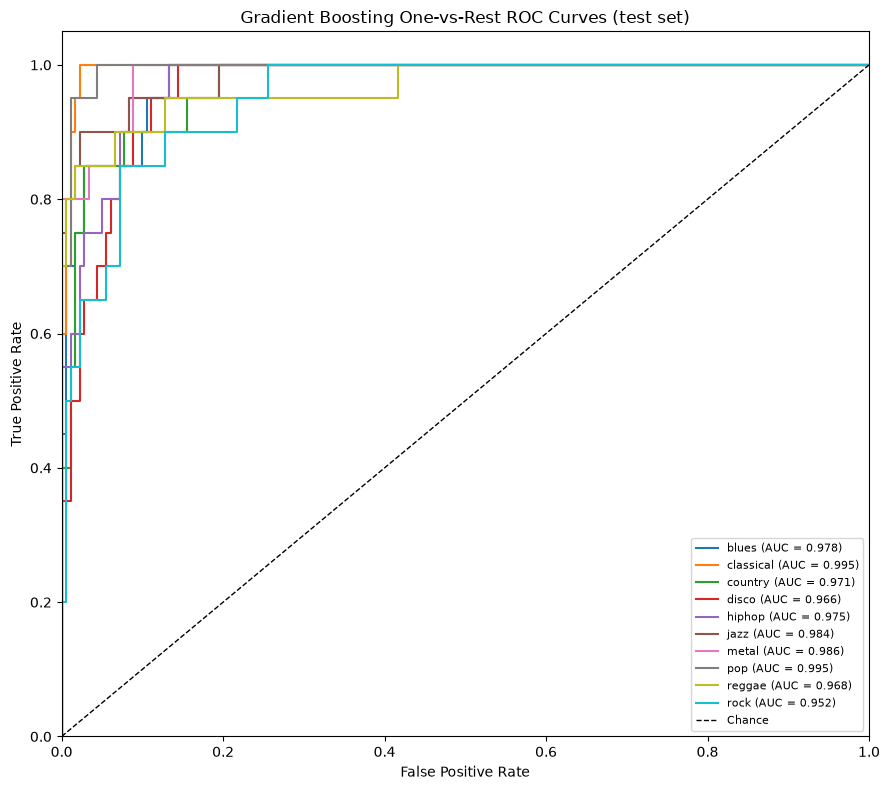

In [130]:
y_score_gb = gb.predict_proba(X_test)

fpr_gb = dict()
tpr_gb = dict()
roc_auc_gb = dict()

for i in range(n_classes):
    fpr_gb[i], tpr_gb[i], _ = roc_curve(y_test_bin[:, i], y_score_gb[:, i])
    roc_auc_gb[i] = auc(fpr_gb[i], tpr_gb[i])

for i, label in enumerate(labelencoder.classes_):
    print(f'{label:10s} AUC: {roc_auc_gb[i]:.4f}')

plt.figure(figsize=(9, 8))

for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr_gb[i], tpr_gb[i], lw=1.5,
             label=f'{label} (AUC = {roc_auc_gb[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gradient Boosting One-vs-Rest ROC Curves (test set)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### NOTE: the AUC numbers (between 0.9519 and 0.9953) are quite high and better than the baseline numbers for other models, including for "rock" and "disco"

### 1.4.6. Gradient Boosting (baseline): macro- and micro- averaged AUC:

In [131]:
roc_auc_macro_gb = roc_auc_score(y_test_bin, y_score_gb, average='macro', multi_class='ovr')
roc_auc_micro_gb = roc_auc_score(y_test_bin, y_score_gb, average='micro')

print(f'Macro-averaged AUC: {roc_auc_macro_gb:.4f}')
print(f'Micro-averaged AUC: {roc_auc_micro_gb:.4f}')

Macro-averaged AUC: 0.9770
Micro-averaged AUC: 0.9776


### 1.4.7. Gradient Boosting: Hyperparameter Tuning:

In [133]:
param_grid_gb = {
    'learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4],  # shrinkage per tree: lower = more cautious, needs more trees
    'n_estimators': [100, 200, 300, 400, 500],    # number of sequential trees to build
    'max_depth': [1, 2, 3, 4, 5]                  # max splits per tree; boosting favors shallow "weak" trees
}

# NOTE: this may take a number of minutes to complete
#       I am going to be patient and wait for it, and am
#       continuing to use Grid Search in order to have a
#       sort of apples-to-apples similar comparison of steps
#       to the previous tuning of other models, instead of the
#       other options such as faster random search with a set number of iterations
gb_grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_tuning_start_time = time.time()
gb_grid_search.fit(X_train, y_train)
gb_tuning_end_time = time.time()
gb_tuning_time = gb_tuning_end_time - gb_tuning_start_time

print(f'Gradient Boosting hyperparameter tuning time: {gb_tuning_time:.2f} seconds')
print(f'Best parameters: {gb_grid_search.best_params_}')
print(f'Best cross-validation accuracy: {gb_grid_search.best_score_:.4f}')

Gradient Boosting hyperparameter tuning time: 3182.25 seconds
Best parameters: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 300}
Best cross-validation accuracy: 0.7850


### 1.4.8. Gradient Boosting (tuned): Evaluate on Test Data, Compare Accuracy Between Baseline and Tuned

In [134]:
gb_tuned = gb_grid_search.best_estimator_

y_pred_gb_tuned = gb_tuned.predict(X_test)

train_accuracy_gb_tuned = accuracy_score(y_train, gb_tuned.predict(X_train))
gb_tuned_accuracy = accuracy_score(y_test, y_pred_gb_tuned)

print('              Train    Test     Gap')
print(f'Original GB:  {train_accuracy_gb:.4f}   {gb_accuracy:.4f}   {train_accuracy_gb - gb_accuracy:.4f}')
print(f'Tuned GB:     {train_accuracy_gb_tuned:.4f}   {gb_tuned_accuracy:.4f}   {train_accuracy_gb_tuned - gb_tuned_accuracy:.4f}')

              Train    Test     Gap
Original GB:  0.9988   0.7800   0.2188
Tuned GB:     0.9988   0.7950   0.2037


#### NOTE: tuning provided only a slight improvement with test data

### 1.4.9.  Gradient Boosting (tuned): Precision, Recall, F1:

In [135]:
gb_tuned_precision = precision_score(y_test, y_pred_gb_tuned, average='macro')
gb_tuned_recall    = recall_score(y_test, y_pred_gb_tuned, average='macro')
gb_tuned_f1        = f1_score(y_test, y_pred_gb_tuned, average='macro')

print('Original GB  ->  Tuned GB')
print(f'Precision (macro): {gb_precision:.4f}  ->  {gb_tuned_precision:.4f}')
print(f'Recall (macro):    {gb_recall:.4f}  ->  {gb_tuned_recall:.4f}')
print(f'F1 score (macro):  {gb_f1:.4f}  ->  {gb_tuned_f1:.4f}')

Original GB  ->  Tuned GB
Precision (macro): 0.7862  ->  0.8025
Recall (macro):    0.7800  ->  0.7950
F1 score (macro):  0.7806  ->  0.7948


### 1.4.10. Gradient Boosting (tuned): Confusion Matrix:

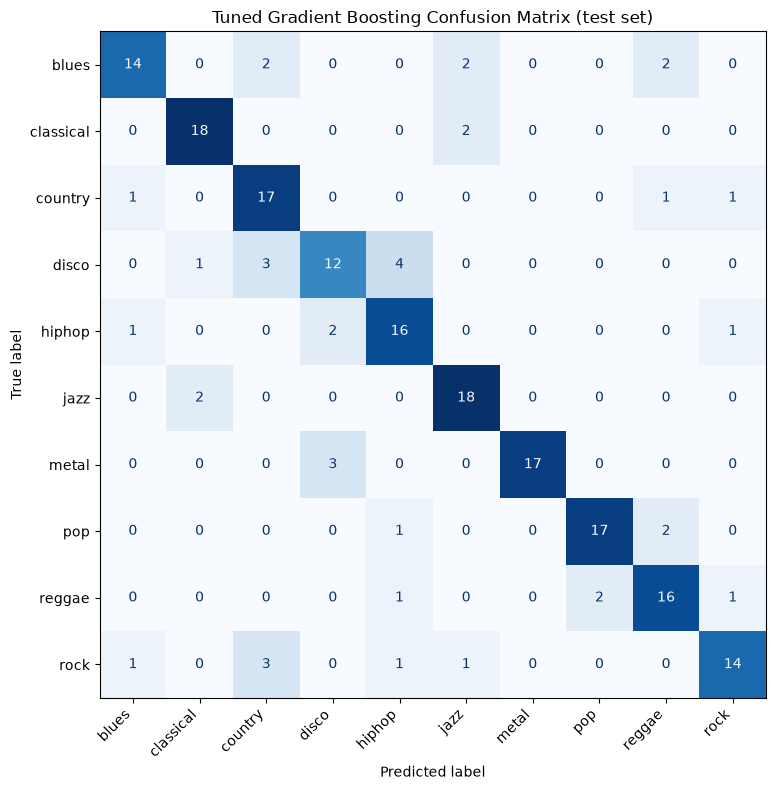

In [136]:
cm_gb_tuned = confusion_matrix(y_test, y_pred_gb_tuned)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_gb_tuned,
                       display_labels=labelencoder.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_title('Tuned Gradient Boosting Confusion Matrix (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### NOTE: from step 1.4.4 (baseline) to step 1.4.10 (tuned), the "rock" genre classification improved from 12/20 to 14/20, but "disco" is only 12/20 in this case.

### 1.4.11.  Gradient Boosting (tuned): AUC (average under curve) and ROC curves:

In [137]:
y_score_gb_tuned = gb_tuned.predict_proba(X_test)

fpr_gb_tuned = dict()
tpr_gb_tuned = dict()
roc_auc_gb_tuned = dict()

for i in range(n_classes):
    fpr_gb_tuned[i], tpr_gb_tuned[i], _ = roc_curve(y_test_bin[:, i], y_score_gb_tuned[:, i])
    roc_auc_gb_tuned[i] = auc(fpr_gb_tuned[i], tpr_gb_tuned[i])

print('Class\tGB (baseline)\t->\tGB (tuned)')
for i, label in enumerate(labelencoder.classes_):
    print(f'{label:10s}\t{roc_auc_gb[i]:.4f}\t->\t{roc_auc_gb_tuned[i]:.4f}')

Class	GB (baseline)	->	GB (tuned)
blues     	0.9781	->	0.9786
classical 	0.9953	->	0.9939
country   	0.9708	->	0.9681
disco     	0.9658	->	0.9672
hiphop    	0.9753	->	0.9808
jazz      	0.9839	->	0.9797
metal     	0.9861	->	0.9864
pop       	0.9950	->	0.9931
reggae    	0.9681	->	0.9786
rock      	0.9519	->	0.9558


#### NOTE: Gradient Boosting (tuned) is showing very good results

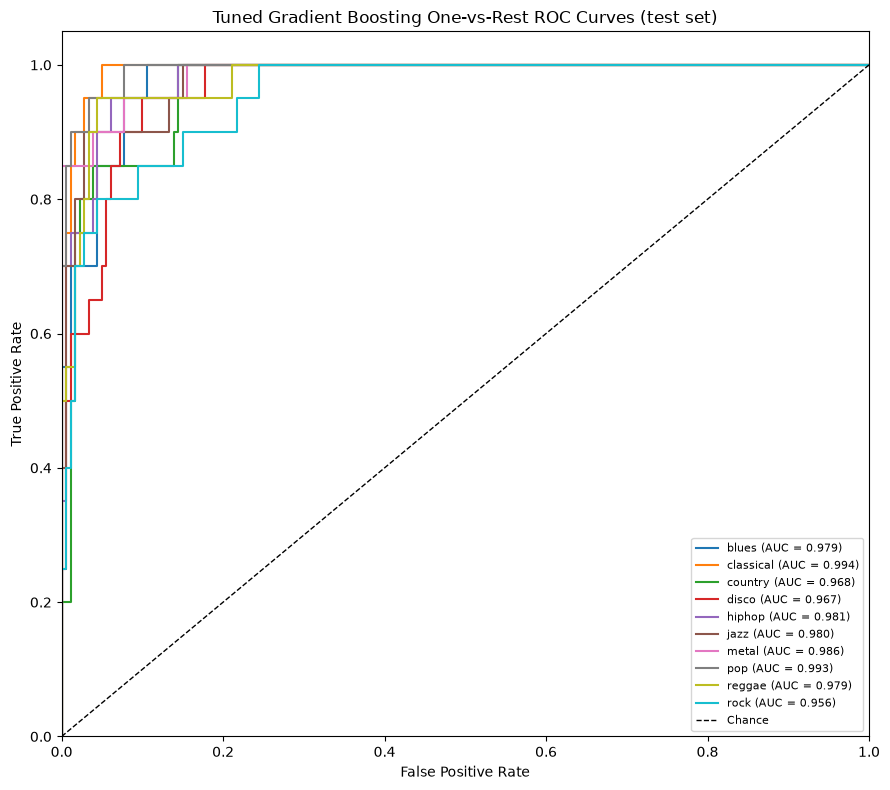

In [138]:
plt.figure(figsize=(9, 8))

for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr_gb_tuned[i], tpr_gb_tuned[i], lw=1.5,
             label=f'{label} (AUC = {roc_auc_gb_tuned[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned Gradient Boosting One-vs-Rest ROC Curves (test set)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 1.4.12.  Gradient Boosting (tuned): macro- and micro- averaged AUC (average under curve):

In [139]:
roc_auc_macro_gb_tuned = roc_auc_score(y_test_bin, y_score_gb_tuned, average='macro', multi_class='ovr')
roc_auc_micro_gb_tuned = roc_auc_score(y_test_bin, y_score_gb_tuned, average='micro')

print('Metric              Baseline GB -> Tuned GB')
print(f'Macro-averaged AUC: {roc_auc_macro_gb:.4f}     -> {roc_auc_macro_gb_tuned:.4f}')
print(f'Micro-averaged AUC: {roc_auc_micro_gb:.4f}     -> {roc_auc_micro_gb_tuned:.4f}')

Metric              Baseline GB -> Tuned GB
Macro-averaged AUC: 0.9770     -> 0.9782
Micro-averaged AUC: 0.9776     -> 0.9788


### 1.5.  Summary of the Four Classical Machine Learning Models:

#### Compare the models in terms of:
* performance
* training time
* complexity

### 1.5.1.  Compare Performance: Accuracy, Precision, Recall, F1, Macro-/Micro- AUC:

In [141]:
summary_performance = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'k-NN', 'Gradient Boosting'],
    'Test Accuracy': [svm_tuned_accuracy, rf_tuned_accuracy, knn_tuned_accuracy, gb_tuned_accuracy],
    'Precision (macro)': [svm_tuned_precision, rf_tuned_precision, knn_tuned_precision, gb_tuned_precision],
    'Recall (macro)': [svm_tuned_recall, rf_tuned_recall, knn_tuned_recall, gb_tuned_recall],
    'F1 (macro)': [svm_tuned_f1, rf_tuned_f1, knn_tuned_f1, gb_tuned_f1],
    'Macro AUC': [roc_auc_macro_tuned, roc_auc_macro_rf_tuned, roc_auc_macro_knn_tuned, roc_auc_macro_gb_tuned],
    'Micro AUC': [roc_auc_micro_tuned, roc_auc_micro_rf_tuned, roc_auc_micro_knn_tuned, roc_auc_micro_gb_tuned]
})

summary_performance

,Model,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC
0,SVM,0.765,0.768611,0.765,0.764319,0.943611,0.945317
1,Random Forest,0.820,0.820470,0.820,0.818040,0.975306,0.976993
2,k-NN,0.690,0.707873,0.690,0.690255,0.905028,0.905900
3,Gradient Boosting,0.795,0.802499,0.795,0.794836,0.978222,0.978806


#### Summary:

Random Forest achieved the best overall classification performance among the four tuned models, with the highest accuracy, precision, recall, and F1 score (0.8200, 0.8205, 0.8200, 0.8180 respectively).

Gradient Boosting achieved the highest macro- and micro-averaged AUC (0.9782 and 0.9788). Random Forest's AUC was the second-best, despite lower raw accuracy. This indicates that Gradient Boosting ranks class probabilities slightly more reliably even though Random Forest is more often correct at the default decision threshold.

Rock and Disco were the two most difficult genres to classify across all four models regardless of algorithm or tuning. Classical and pop were consistently the easiest.  These patterns point to patterns of the underlying audio features in the data set, rather than a limitation specific to any one model.

### 1.5.2. Compare Training Times:

In [144]:
summary_time = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'k-NN', 'Gradient Boosting'],
    'Baseline Training Time (s)': [svm_training_time, rf_training_time, knn_training_time, gb_training_time],
    'Hyperparameter Tuning Time (s)': [svm_tuning_time, rf_tuning_time, knn_tuning_time, gb_tuning_time]
})

summary_time

,Model,Baseline Training Time (s),Hyperparameter Tuning Time (s)
0,SVM,0.042112,9.288851
1,Random Forest,0.511539,112.154014
2,k-NN,0.003265,5.576508
3,Gradient Boosting,9.865697,3182.253683


#### Summary:

The time to train and tune the four models varied widely.

k-NN trained virtually instantly (0.003 seconds) since it performs no real fitting and simply stores the training data, while SVM (0.042s) and Random Forest (0.512s) were also fast at baseline.

Gradient Boosting was by far the slowest to train (9.87 seconds baseline) due to its sequential tree-building process).

This gap widened dramatically during hyperparameter tuning. k-NN's grid search completed in 5.58 seconds versus Gradient Boosting's 3,182 seconds (nearly 53 minutes) for a 125-combination grid, making it by far the most computationally expensive model in this comparison. However, the Gradient Boosting tuning time was in part due to choosing more options in the grid for each hyper-parameter, in order to better confirm which value was the best - after an early attempt with fewer values for each parameter was inconclusive.

### 1.5.3. Compare Complexity:

In [147]:
print('SVM:')
print(f'  Support vectors: {svm_tuned.support_vectors_.shape[0]} of {X_train.shape[0]} training samples')
print(f'  Kernel: {svm_tuned.kernel}')
# SVM's rough equivalent: one "parameter" per support vector per feature, plus bias terms
svm_effective_params = svm_tuned.support_vectors_.shape[0] * X_train.shape[1]
print(f'  SVM effective parameters (support vectors x features): {svm_effective_params:,}')

print('\nRandom Forest:')
print(f'  Trees: {rf_tuned.n_estimators}')
print(f'  Max depth per tree: {rf_tuned.max_depth}')
print(f'  Avg actual tree depth: {sum(tree.tree_.max_depth for tree in rf_tuned.estimators_) / len(rf_tuned.estimators_):.1f}')
rf_total_nodes = sum(tree.tree_.node_count for tree in rf_tuned.estimators_)
print(f'  Random Forest total decision nodes (across 300 trees):  {rf_total_nodes:,}')

print('\nk-NN:')
print(f'  k (neighbors): {knn_tuned.n_neighbors}')
print(f'  Stored training samples: {X_train.shape[0]} (entire training set kept in memory)')
print(f'  k-NN: no trained parameters — stores all {X_train.shape[0]} training samples directly')

print('\nGradient Boosting:')
print(f'  Trees: {gb_tuned.n_estimators}')
print(f'  Max depth per tree: {gb_tuned.max_depth}')
gb_total_nodes = sum(estimator[0].tree_.node_count for estimator in gb_tuned.estimators_)
print(f'  Gradient Boosting total decision nodes (across 300 trees): {gb_total_nodes:,}')



SVM:
  Support vectors: 663 of 800 training samples
  Kernel: rbf
  SVM effective parameters (support vectors x features): 38,454

Random Forest:
  Trees: 300
  Max depth per tree: 20
  Avg actual tree depth: 14.2
  Random Forest total decision nodes (across 300 trees):  75,074

k-NN:
  k (neighbors): 3
  Stored training samples: 800 (entire training set kept in memory)
  k-NN: no trained parameters — stores all 800 training samples directly

Gradient Boosting:
  Trees: 300
  Max depth per tree: 2
  Gradient Boosting total decision nodes (across 300 trees): 2,076


#### Summary:

Model complexity is measured differently across the four algorithms, and therefore is hard to compare in a truly apples-to-apples way.

Random Forest was the most structurally complex by total decision-node count (75,074 nodes across 300 deep trees, averaging depth 14.2), roughly 36 times more than Gradient Boosting's 2,076 nodes (300 trees deliberately capped at depth 2).

SVM's complexity is best captured by its 663 support vectors (83% of the training set) requiring 38,454 effective parameters to define its decision boundary, while k-NN is the simplest by trained-parameter count (it has none) but the most expensive at prediction time, since every query must be compared against all 800 stored training samples.